In [5]:
!!pip install -U -q langchain-google-genai

['\x1b[?25l   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b0.0/68.6 kB\x1b \x1b?\x1b eta \x1b-:--:--\x1b',
 '\x1b[2K   \x1b━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\x1b \x1b68.6/68.6 kB\x1b \x1b3.9 MB/s\x1b eta \x1b0:00:00\x1b',
 '\x1b[?25h']

# Instantiating the Language Model

In [18]:
import os
from langchain.chat_models import init_chat_model
from google.colab import userdata

os.environ["GOOGLE_API_KEY"] = userdata.get("GOOGLE_API_KEY")

model = init_chat_model(
    model="gemini-2.5-flash",
    model_provider="google_genai"
)


# Generation Prompt for Posts

In [19]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

In [20]:
generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a professional LinkedIn content assistant tasked with crafting engaging, insightful, and well-structured LinkedIn posts."
            " Generate the best LinkedIn post possible for the user's request."
            " If the user provides feedback or critique, respond with a refined version of your previous attempts, improving clarity, tone, or engagement as needed.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

# Creating the Chain for LinkedIn Post Generation

In [22]:
generate_chain = generation_prompt | model

<br>

### **Reflection Prompt for LinkedIn Post Critique**

In this step, we define the **`reflection_prompt`**, which is a template used for generating critiques and recommendations to improve a user's LinkedIn post. This prompt guides the model to assess the quality of a LinkedIn post and provide structured, actionable feedback.

- **`reflection_prompt`**: The system message here instructs the model to act as a professional LinkedIn content strategist. The model will evaluate the post based on factors like tone, structure, clarity, engagement potential, formatting, and relevance. It then generates feedback to help improve the post’s overall effectiveness and alignment with LinkedIn best practices.


In [23]:
reflection_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are a professional LinkedIn content strategist and thought leadership expert. Your task is to critically evaluate the given LinkedIn post and provide a comprehensive critique. Follow these guidelines:

        1. Assess the post’s overall quality, professionalism, and alignment with LinkedIn best practices.
        2. Evaluate the structure, tone, clarity, and readability of the post.
        3. Analyze the post’s potential for engagement (likes, comments, shares) and its effectiveness in building professional credibility.
        4. Consider the post’s relevance to the author’s industry, audience, or current trends.
        5. Examine the use of formatting (e.g., line breaks, bullet points), hashtags, mentions, and media (if any).
        6. Evaluate the effectiveness of any call-to-action or takeaway.

        Provide a detailed critique that includes:
        - A brief explanation of the post’s strengths and weaknesses.
        - Specific areas that could be improved.
        - Actionable suggestions for enhancing clarity, engagement, and professionalism.

        Your critique will be used to improve the post in the next revision step, so ensure your feedback is thoughtful, constructive, and practical.
        """
    ),
    MessagesPlaceholder(variable_name="messages")
])

### **Creating the Reflect Chain**
The **`reflect_chain`** is created by combining the **`reflection_prompt`** with the language model (LLM). This chain allows the model to evaluate and provide feedback on the generated post.


In [25]:
reflect_chain = reflection_prompt | model

# Defining the Agent State for Reflection Agent

In [32]:
from langgraph.graph import MessageGraph
from typing import List, Annotated, TypedDict
from langchain.messages import HumanMessage, AIMessage, SystemMessage
from typing import Sequence, List
from langchain_core.messages import BaseMessage, AIMessage

graph = MessageGraph()

/tmp/ipykernel_1890/2906480152.py:7: LangGraphDeprecatedSinceV10: MessageGraph is deprecated in LangGraph v1.0.0, to be removed in v2.0.0. Please use StateGraph with a `messages` key instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  graph = MessageGraph()


In [30]:
class AgentState(TypedDict):
    messages: Annotated[List[HumanMessage | AIMessage | SystemMessage], "add_messages"]


### **Defining the Generation and Reflection  Node**

The `generation_node` function acts as the starting point in the Reflection Agent's workflow. It generates an initial output based on the current state of the conversation, which contains all previous messages (user inputs, AI responses, and system instructions).

- **Input**: The function accepts the `state`, which is a sequence of `BaseMessage` objects (i.e., `HumanMessage`, `AIMessage`, `SystemMessage`). These messages provide the context necessary for generating a meaningful response.

- **Output**: The function uses the `generate_chain` to produce an output by invoking the chain with the `state` as input. The `invoke` function triggers the execution of the chain, where the `messages` in the state guide the chain's generation process. The output is generated based on the context provided by these messages, ensuring that the response is appropriate to the current stage of the conversation or task.


In [33]:
def generation_node(state: Sequence[BaseMessage]) -> List[BaseMessage]:
    generated_post = generate_chain.invoke({"messages": state})
    return [AIMessage(content=generated_post.content)]

In [34]:
def reflection_node(messages: Sequence[BaseMessage]) -> List[BaseMessage]:
    res = reflect_chain.invoke({"messages": messages})  # Passes messages as input to reflect_chain
    return [HumanMessage(content=res.content)]  # Returns the refined message as HumanMessage for feedback

### **Adding the Generate Node to the Graph**

Now we add the generation node to the graph using the `add_node` function. This function takes two parameters:  

1. **Name**: A unique identifier for the node, in this case, `"generate"`.  
2. **Function**: The function to be executed when this node is triggered, here `generation_node`.  


In [35]:
graph.add_node("generate", generation_node)

In [36]:
graph.add_node("reflect", reflection_node)

In [37]:
graph.add_edge("reflect", "generate")


In [38]:
graph.set_entry_point("generate")

<br>

### **Adding a Router Node for Decision Making**

The router node in the graph is responsible for determining whether the workflow should proceed to the reflection phase or terminate. This decision can be made in two ways:  

1. **Predefined Logic**:  
   A simple condition is used to check the number of messages in the state. If the number of messages exceeds 6 (`len(state) > 6`), the workflow ends. Otherwise, it continues to the reflection phase.  

2. **LLM-Based Logic**:  
   Instead of relying on predefined logic, we can integrate an LLM to evaluate the context of the messages and decide whether further reflection is necessary.  

For now, we will implement the predefined logic of checking the message count. Later, we will enhance this functionality by incorporating an LLM to decide dynamically whether to proceed to the reflection phase or end the workflow.


In [39]:
from langgraph.graph import END

In [40]:
def should_continue(state: List[BaseMessage]):
    print(state)
    print(len(state))
    print("----------------------------------------------------------------------")
    if len(state) > 6:
        return END
    return "reflect"

In [41]:
graph.add_conditional_edges("generate", should_continue)

### **Compiling the Workflow**

Now we compile the workflow using `graph.compile()`. This step ensures that all nodes, edges, and conditional logic defined in the graph are connected and ready for execution.  


In [42]:
workflow = graph.compile()

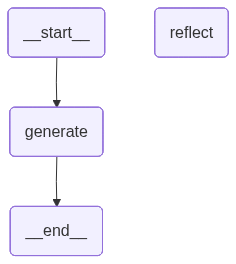

In [46]:
from IPython.display import Image, display
display(Image(workflow.get_graph().draw_mermaid_png()))

# Executing the Workflow

In [47]:
inputs = HumanMessage(content="""Write a linkedin post on getting a software developer job at IBM under 160 characters""")

In [48]:
response = workflow.invoke(inputs)

[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='4544382c-9649-4f9b-a17c-0a35efecfdfc'), AIMessage(content="**Option 1 (Concise & Impactful):**\nBig news! Thrilled to join IBM as a Software Developer. Ready to innovate and grow! #IBM #SoftwareDev\n\n**Option 2 (Slightly more formal):**\nExcited to announce I'm joining IBM as a Software Developer! Looking forward to this new chapter. #IBM #SoftwareDeveloper", additional_kwargs={}, response_metadata={}, id='1aee34fd-1284-4ef3-8942-367ed7206bb3', tool_calls=[], invalid_tool_calls=[])]
2
----------------------------------------------------------------------
[HumanMessage(content='Write a linkedin post on getting a software developer job at IBM under 160 characters', additional_kwargs={}, response_metadata={}, id='4544382c-9649-4f9b-a17c-0a35efecfdfc'), AIMessage(content="**Option 1 (Concise & Impactful):**\nBig news! Thrilled to jo

In [49]:
response[1].content

"**Option 1 (Concise & Impactful):**\nBig news! Thrilled to join IBM as a Software Developer. Ready to innovate and grow! #IBM #SoftwareDev\n\n**Option 2 (Slightly more formal):**\nExcited to announce I'm joining IBM as a Software Developer! Looking forward to this new chapter. #IBM #SoftwareDeveloper"

In [50]:
response[2].content

"\n\n**Option 3 (Focus on future):**\nNew adventure unlocked! Proud to start as a Software Developer at IBM. Let's build the future! #IBMcareers #SoftwareEngineering"

In [51]:
response[-1].content

'You\'re most welcome! I\'m delighted to hear that the critique was valuable and that the specific points resonated with you.\n\nThat "implied call-to-action" in "Let\'s build the future!" is indeed a subtle but powerful way to shift from a mere announcement to an invitation for connection and shared vision. It\'s fantastic that you picked up on that nuance, as it truly elevates the post\'s impact.\n\nAnd absolutely, integrating a professional photo or video, and actively engaging with comments, are critical components for maximizing reach and building genuine connections on LinkedIn. It\'s the full package that turns a good post into a great one.\n\nThank you for the kind words – it\'s rewarding to know that the feedback will help you craft an even more impactful announcement. I\'m here if you need any further assistance!'

In [53]:
!pip install -q pygraphviz

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.0/106.0 kB 4.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  error: subprocess-exited-with-error
  
  × Building wheel for pygraphviz (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for pygraphviz
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (pygraphviz)


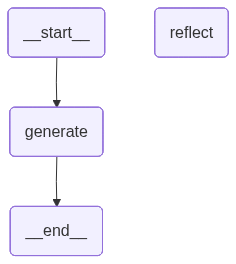

In [55]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))